In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BlackScholesMultiAssetPINN
from utility.model import ModelConfig, EarlyStopping

In [2]:
# Parameters

r = 0.1
sigmas = np.array([0.2, 0.3])
rho = 0.5
corr = np.array([
    [1.0, rho],
    [rho, 1.0]
])
K = 1.0
T = 1.0
S_mins = np.array([0.0, 0.0])
S_maxs = np.array([3.0, 3.0])

In [3]:
input_size = 3
hidden_sizes = [64, 64, 64]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

loss_weights = {
    'variational': 5,
    'terminal': 5,
    'Smax': 3,
    'Smin': 3
}

In [4]:
seed = 24
pinn = BlackScholesMultiAssetPINN(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
pinn.set_loss_weights(loss_weights)

early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
pinn.train(batch_size=4096, epochs=40000, early_stopping=early_stopping)

Iteration 0 | Training Loss: 0.29778772592544556 | Validation Loss: 0.2675166726112366
Iteration 500 | Training Loss: 0.029721220955252647 | Validation Loss: 0.029160240665078163
Iteration 1000 | Training Loss: 0.004327886737883091 | Validation Loss: 0.004308436531573534
Iteration 1500 | Training Loss: 0.0014982891734689474 | Validation Loss: 0.0014804969541728497
Iteration 2000 | Training Loss: 0.0009270058944821358 | Validation Loss: 0.000890119350515306
Iteration 2500 | Training Loss: 0.0006168079562485218 | Validation Loss: 0.0005963360890746117
Iteration 3000 | Training Loss: 0.0004780313465744257 | Validation Loss: 0.0004438324540387839
Iteration 3500 | Training Loss: 0.0003955079591833055 | Validation Loss: 0.0003888900391757488
Iteration 4000 | Training Loss: 0.00038470595609396696 | Validation Loss: 0.0003613521985244006
Iteration 4500 | Training Loss: 0.00035018607741221786 | Validation Loss: 0.00035047653364017606
Iteration 5000 | Training Loss: 0.00035340210888534784 | Vali

KeyboardInterrupt: 

In [5]:
pinn.save(f'../models/bs_pinn_nd/{seed}.pth')

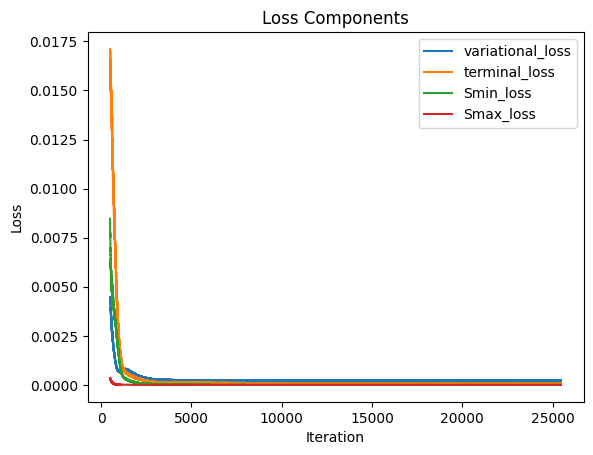

In [6]:
pinn.plot_losses(start_epoch=500, detailed=True)